In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
articles_df = pd.read_csv('/home/huytran/FashionRecSys/fashion-recsys/dataset/subset_1week/articles.csv')
customers_df = pd.read_csv('/home/huytran/FashionRecSys/fashion-recsys/dataset/subset_1week/customers.csv')
transactions_df = pd.read_csv('/home/huytran/FashionRecSys/fashion-recsys/dataset/subset_1week/transactions_train.csv')

In [4]:
print("\n--- Initial Data Inspection (transactions_df) ---")
print("Shape of the dataframe:", transactions_df.shape)
print("\nFirst 5 rows:")
print(transactions_df.head())
print("\nColumn information:")
transactions_df.info()


--- Initial Data Inspection (transactions_df) ---
Shape of the dataframe: (280528, 5)

First 5 rows:
        t_dat                                        customer_id  article_id  \
0  2020-08-09  0004df3751c43c51f79aa24d321f35ce4a1a3ec180c4a1...   832482001   
1  2020-08-09  0004df3751c43c51f79aa24d321f35ce4a1a3ec180c4a1...   802881001   
2  2020-08-09  0004df3751c43c51f79aa24d321f35ce4a1a3ec180c4a1...   783707047   
3  2020-08-09  000fb6e772c5d0023892065e659963da90b1866035558e...   852585002   
4  2020-08-09  000fb6e772c5d0023892065e659963da90b1866035558e...   852585002   

      price  sales_channel_id  
0  0.016932                 1  
1  0.067780                 1  
2  0.005068                 1  
3  0.042356                 2  
4  0.042356                 2  

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 280528 entries, 0 to 280527
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   t_da

In [5]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 280528 entries, 0 to 280527
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   t_dat             280528 non-null  str    
 1   customer_id       280528 non-null  str    
 2   article_id        280528 non-null  int64  
 3   price             280528 non-null  float64
 4   sales_channel_id  280528 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 10.7 MB


In [6]:
print("\n--- Initial Data Inspection (customers_df) ---")
print("Shape of the dataframe:", customers_df.shape)
print(customers_df.head())


--- Initial Data Inspection (customers_df) ---
Shape of the dataframe: (72291, 7)
                                         customer_id   FN  Active  \
0  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...  1.0     1.0   
1  00009d946eec3ea54add5ba56d5210ea898def4b46c685...  1.0     1.0   
2  0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...  1.0     1.0   
3  00025f8226be50dcab09402a2cacd520a99e112fe01fdd...  1.0     1.0   
4  0002db27a1651998a3de4463437b580b45dfa7d8107afa...  NaN     NaN   

  club_member_status fashion_news_frequency   age  \
0             ACTIVE              Regularly  52.0   
1             ACTIVE              Regularly  56.0   
2             ACTIVE              Regularly  44.0   
3             ACTIVE              Regularly  25.0   
4             ACTIVE                   NONE  19.0   

                                         postal_code  
0  25fa5ddee9aac01b35208d01736e57942317d756b32ddd...  
1  b31984b20a8c478de38eaf113c581ff64e63c4242e607b...  
2  930b19ae7db8abb

In [7]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72291 entries, 0 to 72290
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             72291 non-null  str    
 1   FN                      33778 non-null  float64
 2   Active                  33335 non-null  float64
 3   club_member_status      72176 non-null  str    
 4   fashion_news_frequency  72093 non-null  str    
 5   age                     72000 non-null  float64
 6   postal_code             72291 non-null  str    
dtypes: float64(3), str(4)
memory usage: 3.9 MB


In [8]:
print("\n--- Initial Data Inspection (articles_df) ---")
print("Shape of the dataframe:", articles_df.shape)
print(articles_df.head())


--- Initial Data Inspection (articles_df) ---
Shape of the dataframe: (19284, 25)
   article_id  product_code                  prod_name  product_type_no  \
0   108775044        108775                  Strap top              253   
1   111565001        111565        20 den 1p Stockings              304   
2   111586001        111586  Shape Up 30 den 1p Tights              273   
3   111593001        111593   Support 40 den 1p Tights              304   
4   111609001        111609          200 den 1p Tights              304   

  product_type_name  product_group_name  graphical_appearance_no  \
0          Vest top  Garment Upper body                  1010016   
1  Underwear Tights      Socks & Tights                  1010016   
2   Leggings/Tights  Garment Lower body                  1010016   
3  Underwear Tights      Socks & Tights                  1010016   
4  Underwear Tights      Socks & Tights                  1010016   

  graphical_appearance_name  colour_group_code colour_gro

In [9]:
articles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19284 entries, 0 to 19283
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   article_id                    19284 non-null  int64
 1   product_code                  19284 non-null  int64
 2   prod_name                     19284 non-null  str  
 3   product_type_no               19284 non-null  int64
 4   product_type_name             19284 non-null  str  
 5   product_group_name            19284 non-null  str  
 6   graphical_appearance_no       19284 non-null  int64
 7   graphical_appearance_name     19284 non-null  str  
 8   colour_group_code             19284 non-null  int64
 9   colour_group_name             19284 non-null  str  
 10  perceived_colour_value_id     19284 non-null  int64
 11  perceived_colour_value_name   19284 non-null  str  
 12  perceived_colour_master_id    19284 non-null  int64
 13  perceived_colour_master_name  19284 non-nu

In [10]:
transactions_df['t_dat'] = pd.to_datetime(transactions_df['t_dat'])

print("\n--- Missing Value Check ---")
print("Missing values in transactions_df:\n", transactions_df.isnull().sum())
print("\nMissing values in customers_df:\n", customers_df.isnull().sum())
print("\nMissing values in articles_df:\n", articles_df.isnull().sum())

customers_df['club_member_status'].fillna('UNKNOWN', inplace=True)
customers_df['fashion_news_frequency'].fillna('None', inplace=True)

customers_df['age'].fillna(customers_df['age'].median(), inplace=True)


--- Missing Value Check ---
Missing values in transactions_df:
 t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

Missing values in customers_df:
 customer_id                   0
FN                        38513
Active                    38956
club_member_status          115
fashion_news_frequency      198
age                         291
postal_code                   0
dtype: int64

Missing values in articles_df:
 article_id                       0
product_code                     0
prod_name                        0
product_type_no                  0
product_type_name                0
product_group_name               0
graphical_appearance_no          0
graphical_appearance_name        0
colour_group_code                0
colour_group_name                0
perceived_colour_value_id        0
perceived_colour_value_name      0
perceived_colour_master_id       0
perceived_colour_master_name     0
department_no     

/tmp/ipykernel_4984/2806462022.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  customers_df['club_member_status'].fillna('UNKNOWN', inplace=True)
/tmp/ipykernel_4984/2806462022.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace met

0        52.0
1        56.0
2        44.0
3        25.0
4        19.0
         ... 
72286    26.0
72287    25.0
72288    24.0
72289    21.0
72290    24.0
Name: age, Length: 72291, dtype: float64

In [11]:
print("\n--- Merging Dataframes ---")
merged_df = pd.merge(transactions_df, customers_df, on='customer_id', how='left')
merged_df = pd.merge(merged_df, articles_df, on='article_id', how='left')

print("Shape of the merged dataframe:", merged_df.shape)
print("First 5 rows of the merged dataframe:")
print(merged_df.head())
print("Column information of the merged dataframe:")
merged_df.info()

# Create new features
merged_df['sales_dayofweek'] = merged_df['t_dat'].dt.day_name()


--- Merging Dataframes ---
Shape of the merged dataframe: (280528, 35)
First 5 rows of the merged dataframe:
       t_dat                                        customer_id  article_id  \
0 2020-08-09  0004df3751c43c51f79aa24d321f35ce4a1a3ec180c4a1...   832482001   
1 2020-08-09  0004df3751c43c51f79aa24d321f35ce4a1a3ec180c4a1...   802881001   
2 2020-08-09  0004df3751c43c51f79aa24d321f35ce4a1a3ec180c4a1...   783707047   
3 2020-08-09  000fb6e772c5d0023892065e659963da90b1866035558e...   852585002   
4 2020-08-09  000fb6e772c5d0023892065e659963da90b1866035558e...   852585002   

      price  sales_channel_id   FN  Active club_member_status  \
0  0.016932                 1  NaN     NaN             ACTIVE   
1  0.067780                 1  NaN     NaN             ACTIVE   
2  0.005068                 1  NaN     NaN             ACTIVE   
3  0.042356                 2  1.0     1.0             ACTIVE   
4  0.042356                 2  1.0     1.0             ACTIVE   

  fashion_news_frequency


--- EDA on Customer Behavior & Buying Patterns ---

--- Overall Sales Trend ---


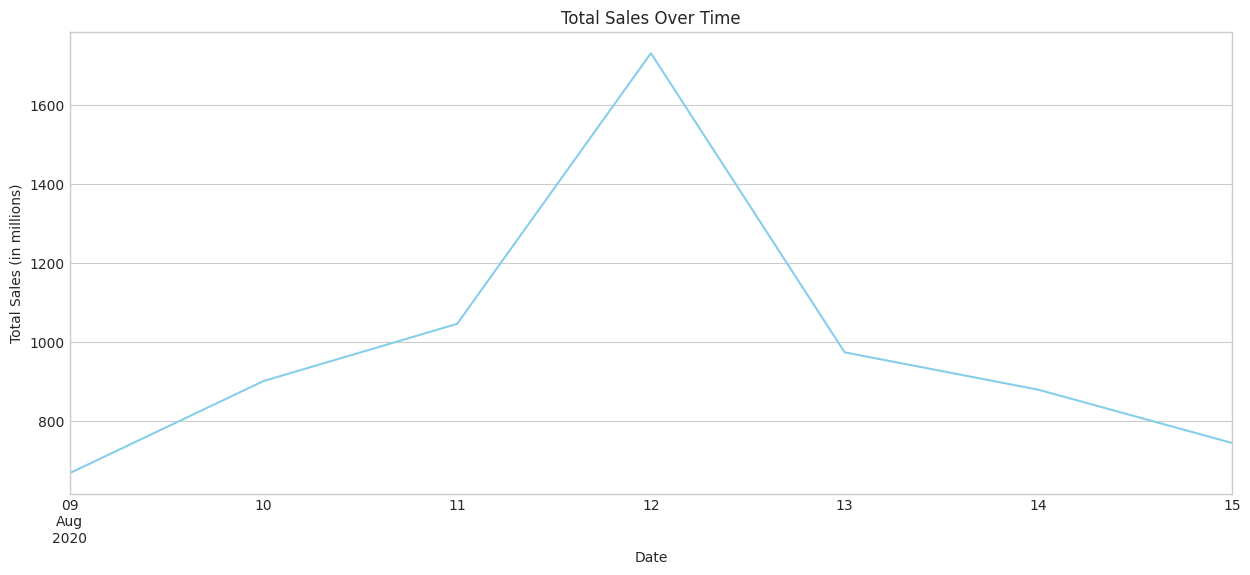

In [12]:
print("\n--- EDA on Customer Behavior & Buying Patterns ---")

print("\n--- Overall Sales Trend ---")
sales_by_date = merged_df.groupby('t_dat')['price'].sum()
plt.figure(figsize=(15, 6))
sales_by_date.plot(title='Total Sales Over Time', color='skyblue')
plt.xlabel('Date')
plt.ylabel('Total Sales (in millions)')
plt.show()


--- Top 10 Bestselling Products ---
   article_id  count                  prod_name
0   812668001    733         B Lola Beach Dress
1   916468003    530                     Bailey
2   923460001    499               Pong pleated
3   806225002    455  All That Jazz Push Up Bra
4   866731001    454    LANA seamless HW tigths
5   351484039    449          Lazer Razer Brief
6   559616013    428  Timeless Push Triangle(1)
7   903062001    402  INVERNESS MID DRESS 24.99
8   882759003    400    Price Mini Curved Brief
9   812668002    399         B Lola Beach Dress


/tmp/ipykernel_4984/3224429519.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_articles_info['count'], y=top_articles_info['prod_name'], palette='viridis')


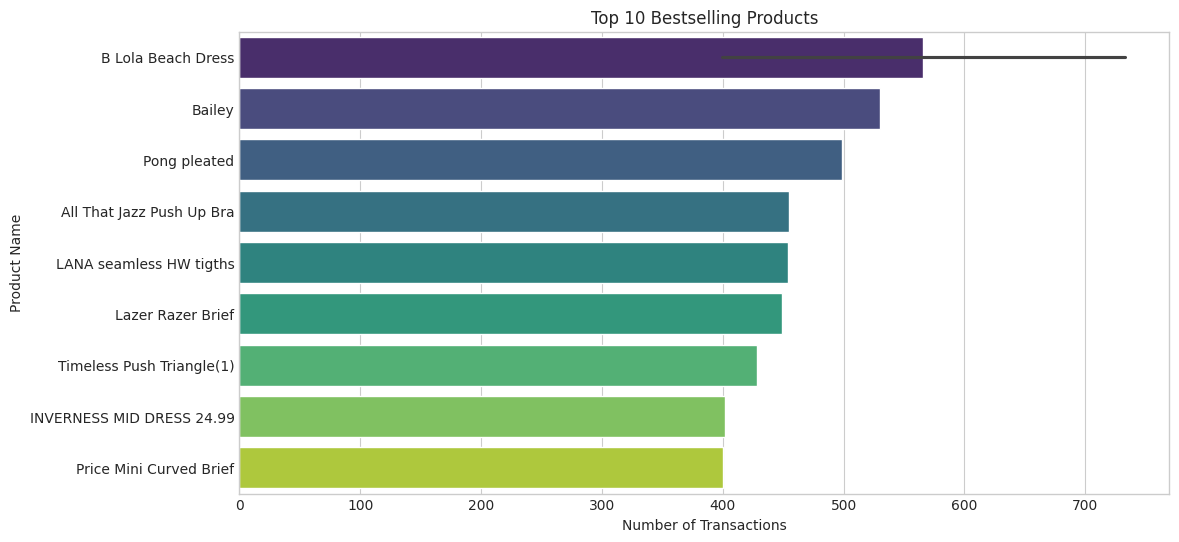

In [13]:
print("\n--- Top 10 Bestselling Products ---")
top_articles = merged_df['article_id'].value_counts().head(10)
top_articles_info = pd.merge(top_articles, articles_df[['article_id', 'prod_name']], on='article_id')
print(top_articles_info)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_articles_info['count'], y=top_articles_info['prod_name'], palette='viridis')
plt.title('Top 10 Bestselling Products')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Name')
plt.show()


--- Top 10 Bestselling Product Groups ---


/tmp/ipykernel_4984/1612124250.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_prod_groups.values, y=top_prod_groups.index, palette='magma')


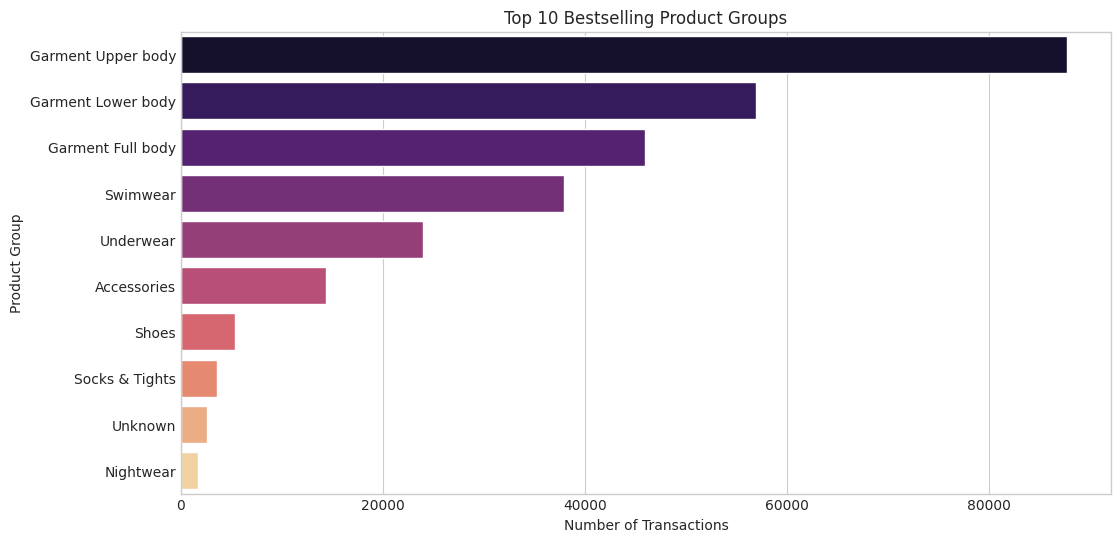

In [14]:
print("\n--- Top 10 Bestselling Product Groups ---")
top_prod_groups = merged_df['product_group_name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_prod_groups.values, y=top_prod_groups.index, palette='magma')
plt.title('Top 10 Bestselling Product Groups')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Group')
plt.show()

In [15]:
print("\n--- Customer Segmentation: RFM Analysis ---")


--- Customer Segmentation: RFM Analysis ---


In [16]:
latest_date = transactions_df['t_dat'].max()
rfm_df = transactions_df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (latest_date - x.max()).days),
    Frequency=('t_dat', 'count'),
    Monetary=('price', 'sum')
)
print("RFM DataFrame Head:")
print(rfm_df.head())

RFM DataFrame Head:
                                                    Recency  Frequency  \
customer_id                                                              
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe...        3          4   
00009d946eec3ea54add5ba56d5210ea898def4b46c6857...        1          4   
0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37e...        4          8   
00025f8226be50dcab09402a2cacd520a99e112fe01fddd...        1          3   
0002db27a1651998a3de4463437b580b45dfa7d8107afa7...        1          1   

                                                    Monetary  
customer_id                                                   
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe...  0.128746  
00009d946eec3ea54add5ba56d5210ea898def4b46c6857...  0.098339  
0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37e...  0.116814  
00025f8226be50dcab09402a2cacd520a99e112fe01fddd...  0.122831  
0002db27a1651998a3de4463437b580b45dfa7d8107afa7...  0.059305  


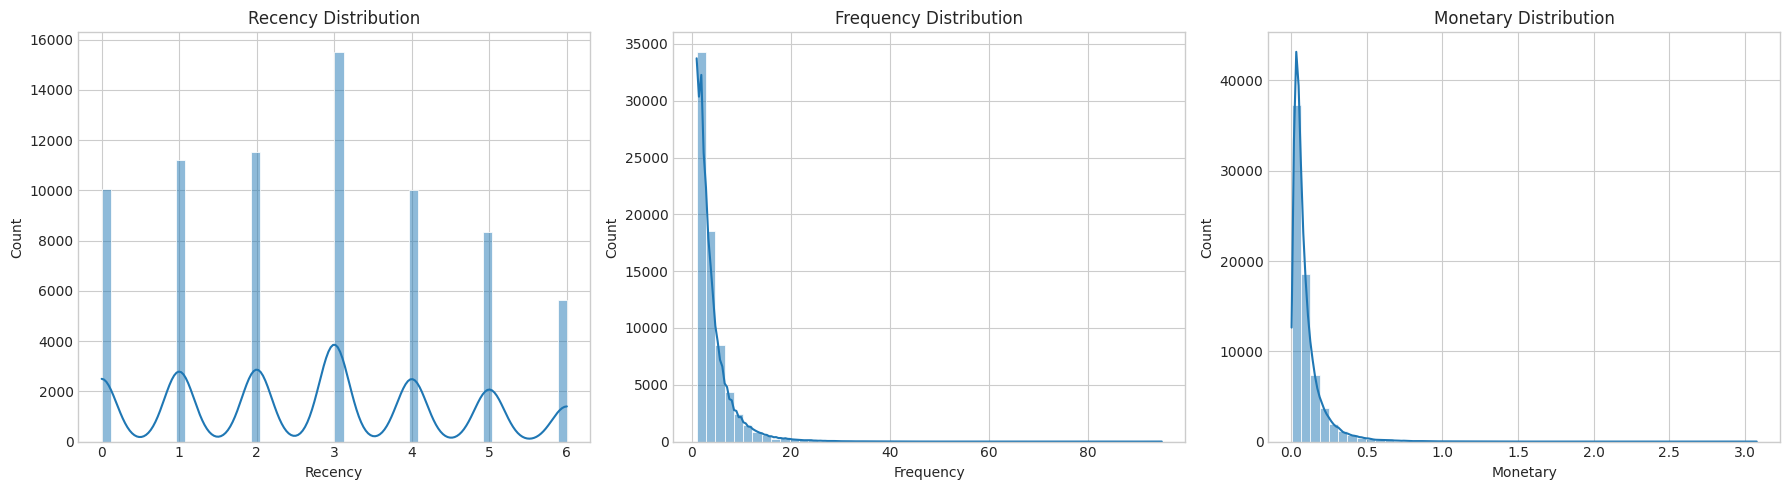

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_df['Recency'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')
sns.histplot(rfm_df['Frequency'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')
sns.histplot(rfm_df['Monetary'], bins=50, kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.show()


--- Age and Spending Behavior ---


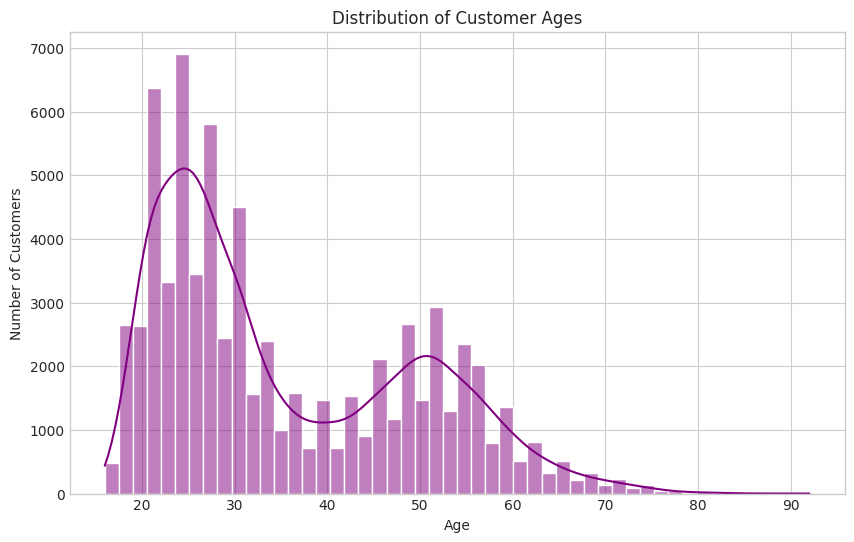

In [18]:
print("\n--- Age and Spending Behavior ---")
plt.figure(figsize=(10, 6))
sns.histplot(customers_df['age'], bins=50, kde=True, color='purple')
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipykernel_4984/3217013781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spending_by_age.index, y=avg_spending_by_age.values, palette='coolwarm')


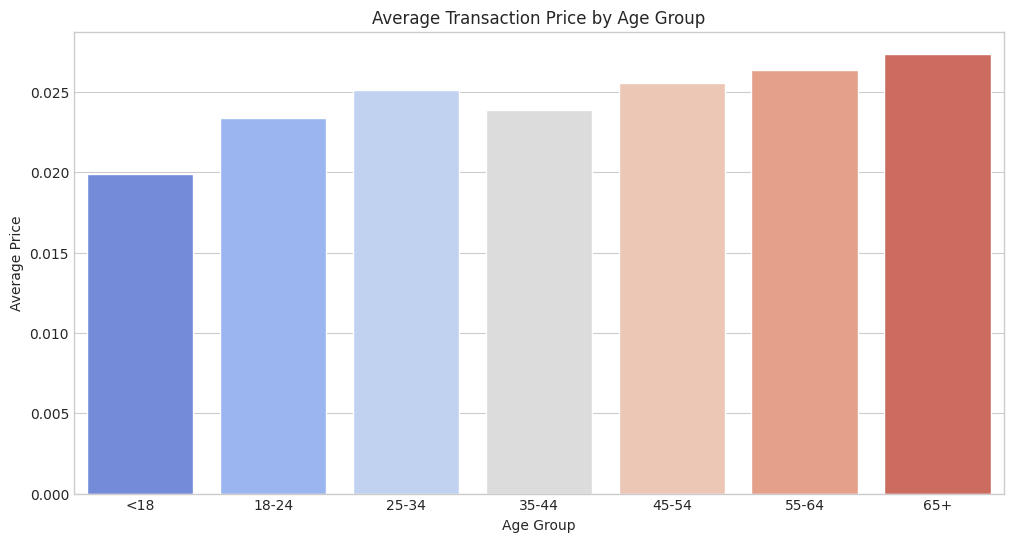

In [19]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
merged_df['age_group'] = pd.cut(merged_df['age'], bins=bins, labels=labels, right=False)

avg_spending_by_age = merged_df.groupby('age_group')['price'].mean().sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_spending_by_age.index, y=avg_spending_by_age.values, palette='coolwarm')
plt.title('Average Transaction Price by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Price')
plt.show()


--- Seasonality and Day of the Week Analysis ---


/tmp/ipykernel_4984/527522592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='pastel')


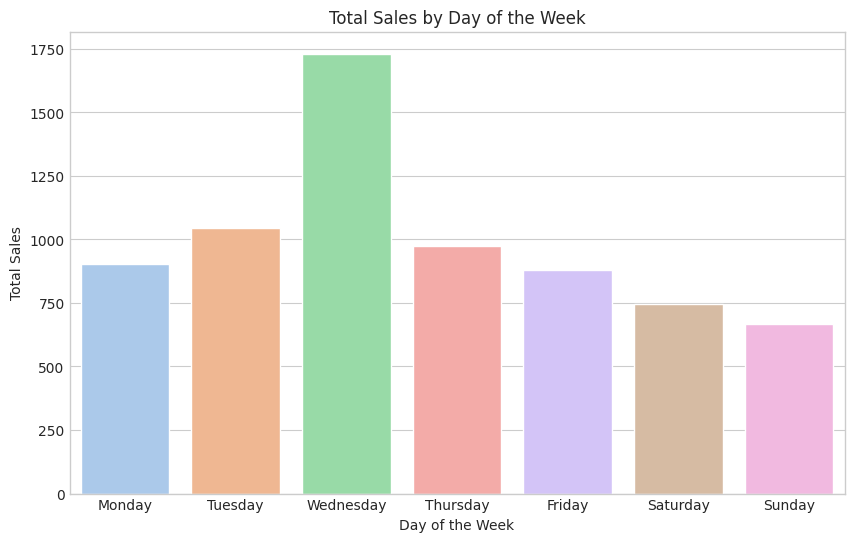

In [20]:
print("\n--- Seasonality and Day of the Week Analysis ---")
# Sales by month
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = merged_df.groupby('sales_dayofweek')['price'].sum().reindex(day_order)
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values, palette='pastel')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')
plt.show()


--- Impact of Fashion News & Club Membership ---


/tmp/ipykernel_4984/3564731319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spending_by_news.index, y=spending_by_news.values, palette='dark')


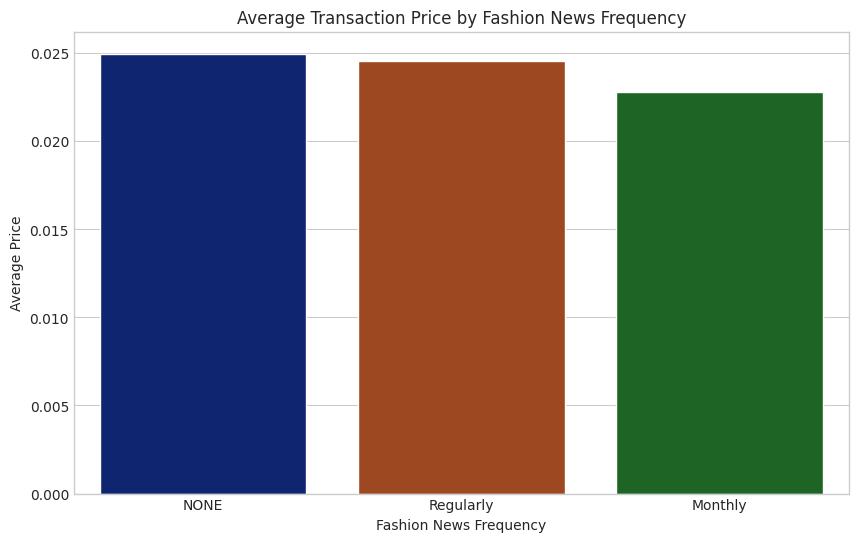

In [21]:
print("\n--- Impact of Fashion News & Club Membership ---")
spending_by_news = merged_df.groupby('fashion_news_frequency')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=spending_by_news.index, y=spending_by_news.values, palette='dark')
plt.title('Average Transaction Price by Fashion News Frequency')
plt.xlabel('Fashion News Frequency')
plt.ylabel('Average Price')
plt.show()

/tmp/ipykernel_4984/3643059924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spending_by_club.index, y=spending_by_club.values, palette='cubehelix')


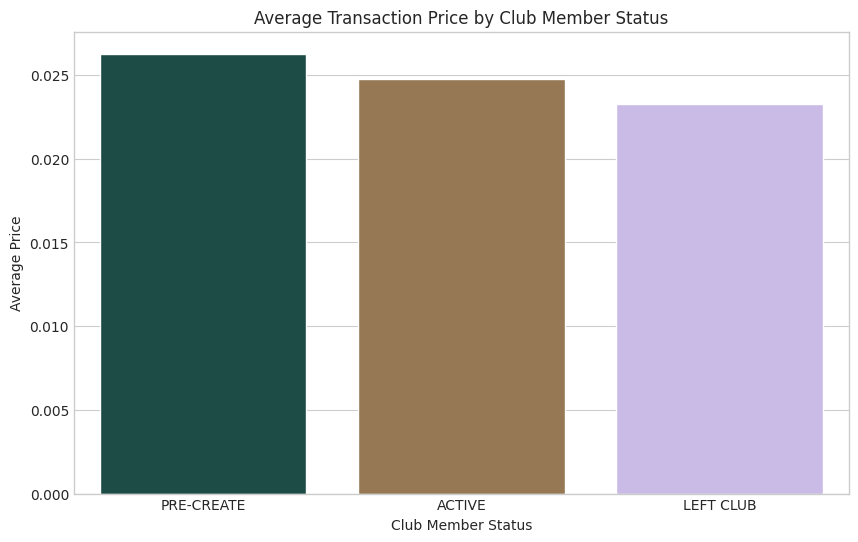

In [22]:
spending_by_club = merged_df.groupby('club_member_status')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=spending_by_club.index, y=spending_by_club.values, palette='cubehelix')
plt.title('Average Transaction Price by Club Member Status')
plt.xlabel('Club Member Status')
plt.ylabel('Average Price')
plt.show()